In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
sns.set(style="whitegrid")
import mlflow
from sklearn.metrics import classification_report 

import warnings                    
warnings.filterwarnings('ignore')

In [3]:
df = pd.read_excel("Credit Card Fraud Detection (Cleaned Data).xlsx")
df

,TransactionType,Location,IsFraud,Amount_Category,MerchantID_Category
0,1,7,0,5,7
1,1,1,0,3,2
2,0,4,0,1,4
3,0,5,0,4,10
4,0,6,0,1,5
...,...,...,...,...,...
99995,1,7,0,2,3
99996,1,7,0,1,8
99997,0,7,0,4,7
99998,0,5,0,4,7


In [4]:
x = df.drop("IsFraud",axis=1)
y = df["IsFraud"]

**Random State Number**

In [5]:
train = []
test = []
cv = []

for i in range(0,101):
    from sklearn.model_selection import train_test_split
    x_train,x_test,y_train,y_test = train_test_split(x,y, test_size=0.2,random_state = i)

    from sklearn.linear_model import LogisticRegression
    log = LogisticRegression()
    log.fit(x_train,y_train)

    y_pred_train = log.predict(x_train)
    y_pred_test = log.predict(x_test)

    from sklearn.metrics import accuracy_score
    train.append(accuracy_score(y_train,y_pred_train))
    test.append(accuracy_score(y_test, y_pred_test))

    from sklearn.model_selection import cross_val_score
    cv.append(cross_val_score(log,x_train,y_train,cv=5,scoring="accuracy").mean())

em = pd.DataFrame({"train":train,"test":test,"cv":cv})
gm = em[(abs(em["train"]-em["test"])<=0.05)&(abs(em["test"]-em["cv"])<=0.05)]
print("best_random_number:",gm[gm["cv"]==gm["cv"].max()].index.to_list()[0])

best_random_number: 23


**Train-Test-Split**

In [6]:
x_train,x_test,y_train,y_test = train_test_split(x,y,train_size=0.8,random_state=23 )

In [7]:
y_train.value_counts()

IsFraud
0    79225
1      775
Name: count, dtype: int64

**Imbalance Dataset handling**

In [8]:
from imblearn.under_sampling import RandomUnderSampler
rs = RandomUnderSampler(random_state=23 )
x_train, y_train = rs.fit_resample(x_train, y_train)

y_train.value_counts()

IsFraud
0    775
1    775
Name: count, dtype: int64

## Modelling & Evaluation

**Initializing MLFlow**

In [21]:
mlflow.set_experiment("Credit Card Fraud Detection")
mlflow.set_tracking_uri("http://127.0.0.1:5000/")

2025/10/17 13:20:08 INFO mlflow.tracking.fluent: Experiment with name 'Credit Card Fraud Detection' does not exist. Creating a new experiment.


**Logistic Regression**

In [26]:
mlflow.autolog()
with mlflow.start_run(run_name= "Logistic Regression"):
    
    from sklearn.linear_model import LogisticRegression
    
    # Train the model
    lr = LogisticRegression(random_state=23)
    lr.fit(x_train,y_train)
        
    # Predict on Test set
    y_pred = lr.predict(x_test)
        
    report = classification_report(y_test,y_pred)
    print(report)

mlflow.end_run()

2025/10/17 14:26:01 INFO mlflow.tracking.fluent: Autologging successfully enabled for sklearn.
2025/10/17 14:26:01 INFO mlflow.tracking.fluent: Autologging successfully enabled for statsmodels.


              precision    recall  f1-score   support

           0       0.99      0.49      0.65     19775
           1       0.01      0.47      0.02       225

    accuracy                           0.49     20000
   macro avg       0.50      0.48      0.34     20000
weighted avg       0.98      0.49      0.65     20000

🏃 View run Logistic Regression at: http://127.0.0.1:5000/#/experiments/234657256295560250/runs/746c0bb84b734cdeacb0cec9f8ff7404
🧪 View experiment at: http://127.0.0.1:5000/#/experiments/234657256295560250


**KNN**

**Finding Best N-Neightbours**

In [56]:
# Disable Autolog function temporarily
mlflow.autolog(disable=True)

from sklearn.neighbors import KNeighborsClassifier
estimator = KNeighborsClassifier()
param_grid = {"n_neighbors":list(range(1,100))}

from sklearn.model_selection import GridSearchCV
cv_classifier = GridSearchCV(estimator,param_grid,cv=5,scoring="recall")

cv_classifier.fit(x_train,y_train)

cv_classifier.best_params_

{'n_neighbors': 65}

In [30]:
# Enabling Autolog function
mlflow.autolog(disable=False)

with mlflow.start_run(run_name= "KNN"):

    from sklearn.neighbors import KNeighborsClassifier
    knn = KNeighborsClassifier(n_neighbors=65 )
    knn.fit(x_train,y_train)
    
    y_pred = knn.predict(x_test)

    report = classification_report(y_test,y_pred)
    print(report)

mlflow.end_run()

2025/10/17 18:49:26 INFO mlflow.tracking.fluent: Autologging successfully enabled for sklearn.
2025/10/17 18:49:26 INFO mlflow.tracking.fluent: Autologging successfully enabled for statsmodels.


              precision    recall  f1-score   support

           0       0.99      0.51      0.68     19775
           1       0.01      0.45      0.02       225

    accuracy                           0.51     20000
   macro avg       0.50      0.48      0.35     20000
weighted avg       0.98      0.51      0.67     20000

🏃 View run KNN at: http://127.0.0.1:5000/#/experiments/234657256295560250/runs/3a9250e31ffa4fd28ebc17c0d8996bcb
🧪 View experiment at: http://127.0.0.1:5000/#/experiments/234657256295560250


### SVM

**Finding Best Parameters-**

In [57]:
mlflow.autolog(disable=True)

from sklearn.svm import SVC

estimator = SVC()
param_grid = {"C":[0.01,0.1,1,10],"kernel":["linear","poly","rbf","sigmoid"]}

svm_grid= GridSearchCV(estimator,param_grid,scoring = "recall",cv=5)
svm_grid.fit(x_train,y_train)

svm_grid.best_params_

{'C': 0.01, 'kernel': 'poly'}

In [32]:
mlflow.autolog(disable=False)


with mlflow.start_run(run_name= "SVM"):
    
    from sklearn.svm import SVC
    s_pca = SVC(C=0.01,kernel="poly")
    s_pca.fit(x_train,y_train)
    
    y_pred = s_pca.predict(x_test)
    
    report = classification_report(y_test,y_pred)
    print(report)

mlflow.end_run()

2025/10/17 19:29:25 INFO mlflow.tracking.fluent: Autologging successfully enabled for sklearn.
2025/10/17 19:29:25 INFO mlflow.tracking.fluent: Autologging successfully enabled for statsmodels.


              precision    recall  f1-score   support

           0       0.99      0.30      0.46     19775
           1       0.01      0.70      0.02       225

    accuracy                           0.31     20000
   macro avg       0.50      0.50      0.24     20000
weighted avg       0.98      0.31      0.46     20000

🏃 View run SVM at: http://127.0.0.1:5000/#/experiments/234657256295560250/runs/7b72159d4c69460eafa887aec9a74375
🧪 View experiment at: http://127.0.0.1:5000/#/experiments/234657256295560250


**Decision Tree**

In [33]:
with mlflow.start_run(run_name= "DT w/o Feature Importance"):
    
    from sklearn.tree import DecisionTreeClassifier, plot_tree
    dt = DecisionTreeClassifier(random_state=23)
    dt.fit(x_train,y_train)
    
    y_pred = dt.predict(x_test)

    report = classification_report(y_test,y_pred)
    print(report)

mlflow.end_run()

              precision    recall  f1-score   support

           0       0.99      0.58      0.73     19775
           1       0.01      0.41      0.02       225

    accuracy                           0.58     20000
   macro avg       0.50      0.50      0.38     20000
weighted avg       0.98      0.58      0.72     20000

🏃 View run DT w/o Feature Importance at: http://127.0.0.1:5000/#/experiments/234657256295560250/runs/6d68c4b0dab44b769583a30e86a830d2
🧪 View experiment at: http://127.0.0.1:5000/#/experiments/234657256295560250


In [34]:
mlflow.autolog(disable=True)

dt.feature_importances_

array([0.14062126, 0.35283407, 0.22832836, 0.2782163 ])

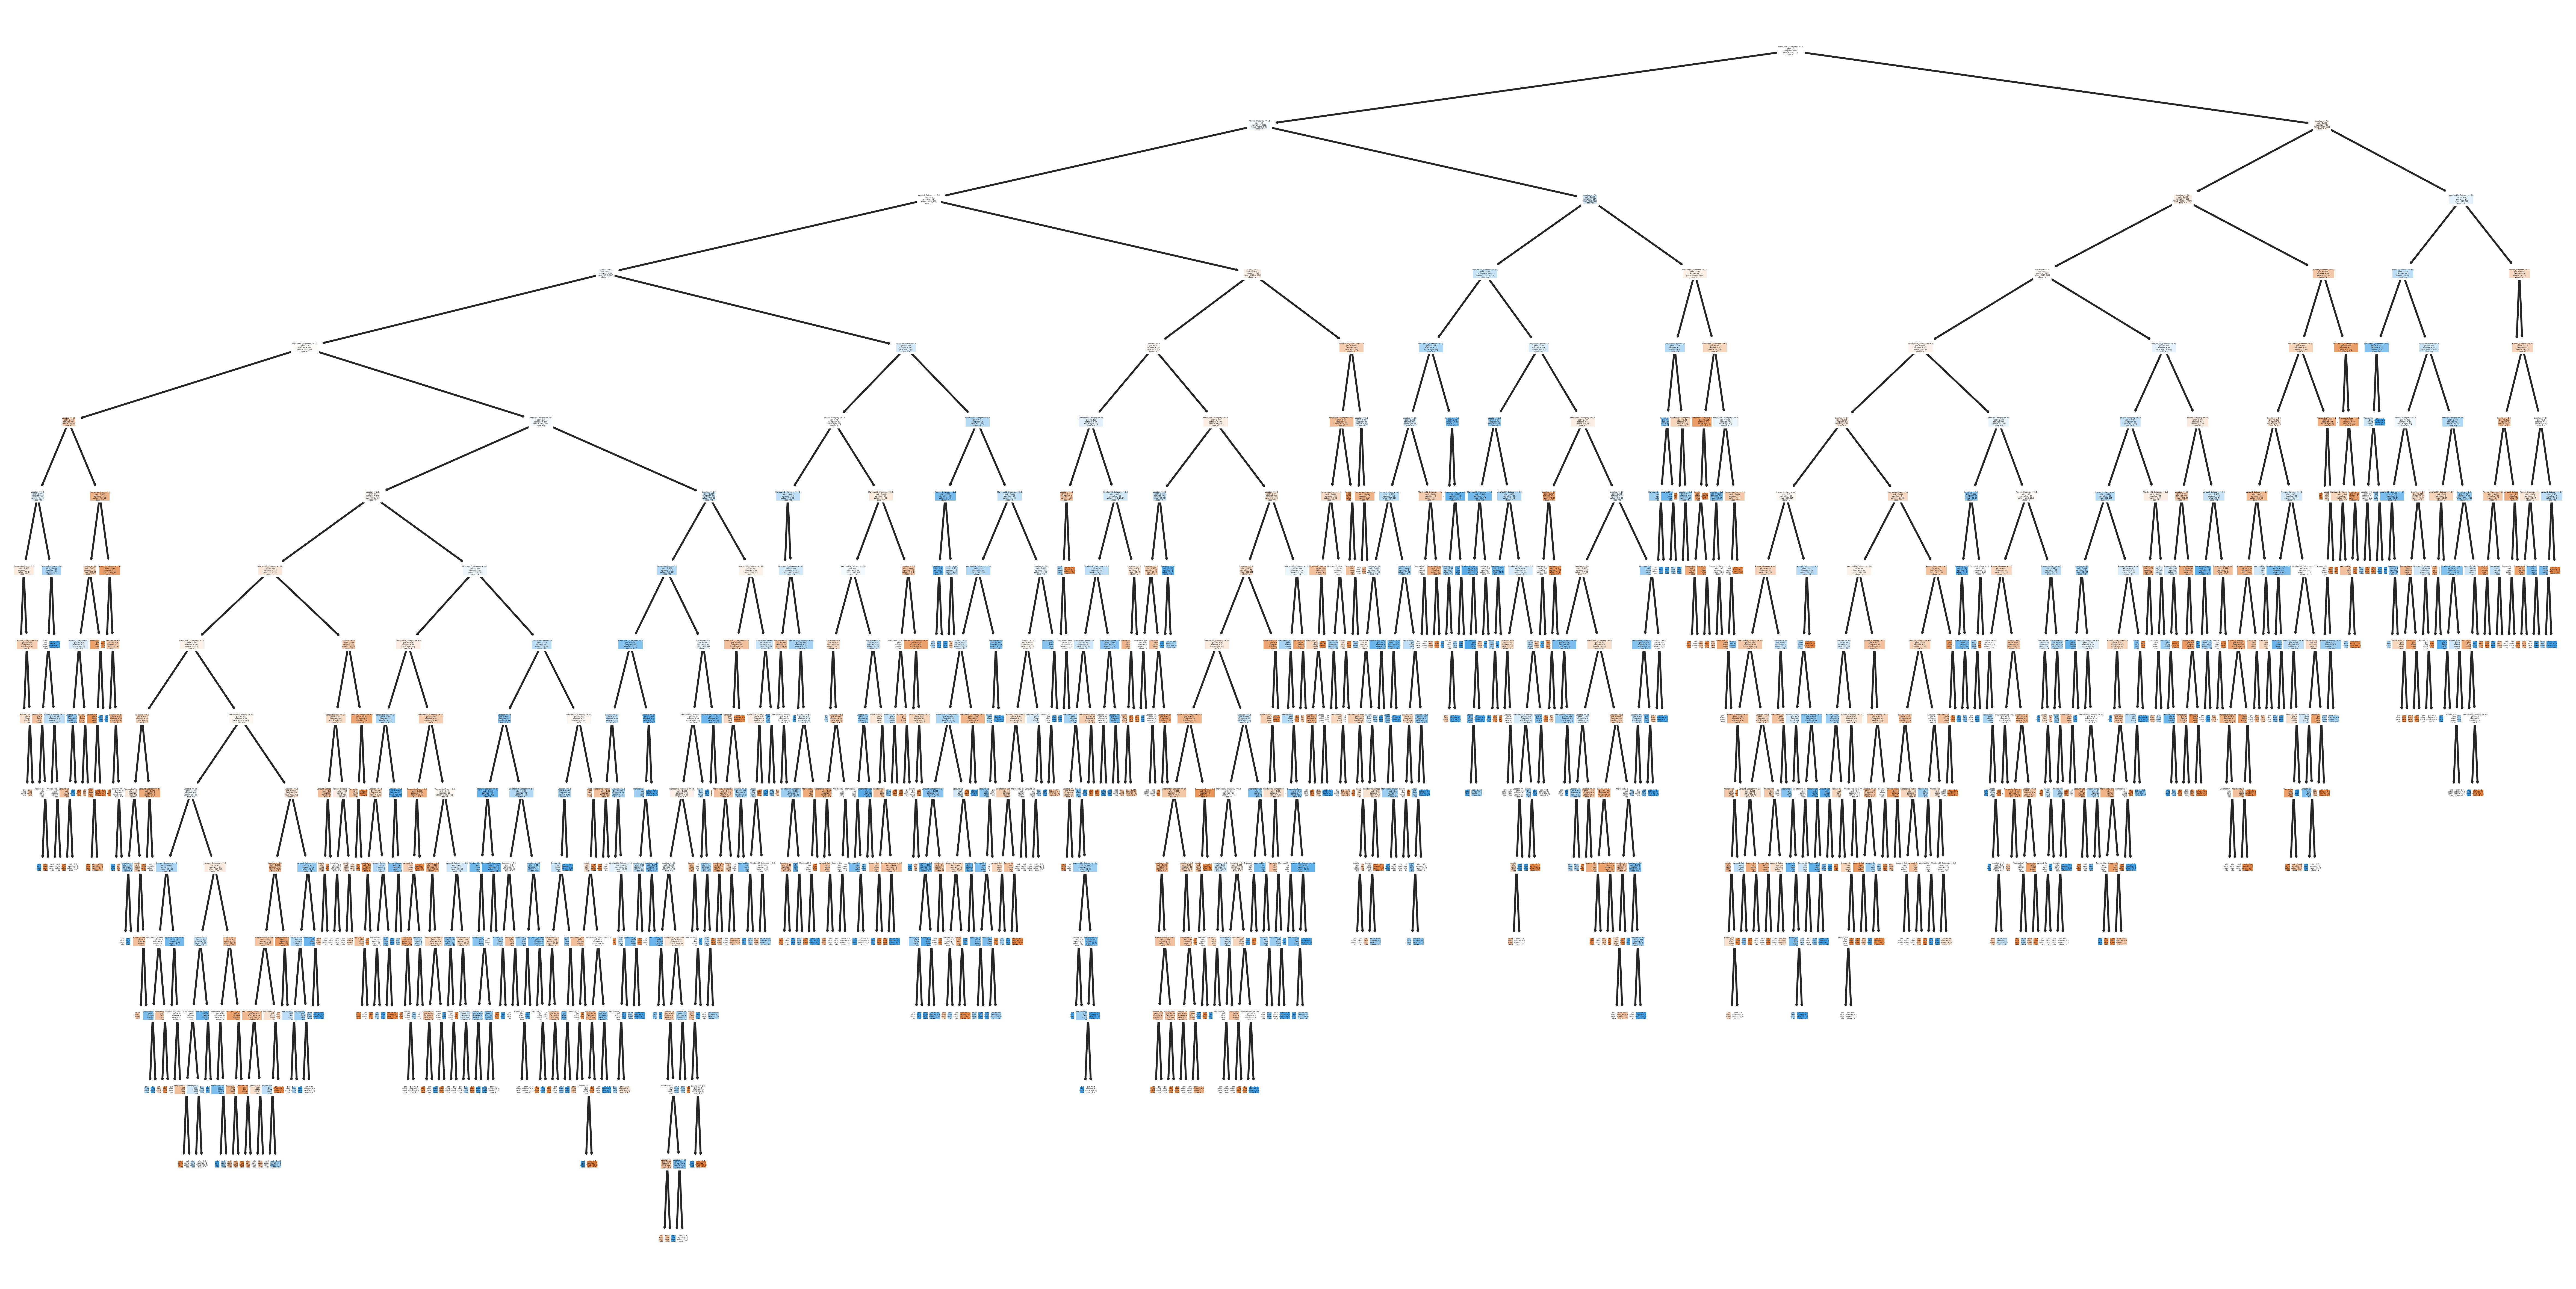

In [35]:
plt.figure(figsize=(24,12),dpi=500)

plot_tree(dt,filled=True,
          feature_names=['TransactionType', 'Location', 'Amount_Category','MerchantID_Category'],class_names=["Y","N"])
plt.show()

In [58]:
estimator = DecisionTreeClassifier(random_state=23 )
param_grid = {"criterion":["gini","entropy"],"max_depth":list(range(1,17))}

grid = GridSearchCV(estimator,param_grid,scoring="recall",cv=5)
grid.fit(x_train,y_train)

grid.best_params_

{'criterion': 'gini', 'max_depth': 1}

In [37]:
feats = pd.DataFrame(data=grid.best_estimator_.feature_importances_,
                    index=x.columns,
                    columns=["Feature Importance"])
feats
feats_im = feats[feats["Feature Importance"]>0]
imp_features = feats_im.index.to_list()
imp_features

['TransactionType', 'Location', 'Amount_Category', 'MerchantID_Category']

In [38]:
mlflow.autolog(disable=False)

with mlflow.start_run(run_name= "DT with Feature Importances"):

    x1= x[imp_features]
    x1_train,x1_test,y1_train,y1_test = train_test_split(x1,y,train_size=0.8,random_state=23 )
    
    dt = DecisionTreeClassifier(criterion="gini",max_depth=1,random_state=23 )
    dt.fit(x1_train,y1_train)
    
    y1_pred_test = dt.predict(x1_test)

    report = classification_report(y_test,y1_pred_test)
    print(report)

mlflow.end_run()

2025/10/17 19:44:54 INFO mlflow.tracking.fluent: Autologging successfully enabled for sklearn.
2025/10/17 19:44:54 INFO mlflow.tracking.fluent: Autologging successfully enabled for statsmodels.


              precision    recall  f1-score   support

           0       0.99      1.00      0.99     19775
           1       0.00      0.00      0.00       225

    accuracy                           0.99     20000
   macro avg       0.49      0.50      0.50     20000
weighted avg       0.98      0.99      0.98     20000

🏃 View run DT with Feature Importances at: http://127.0.0.1:5000/#/experiments/234657256295560250/runs/95c9d839c04542d1a0fffe366f67f62d
🧪 View experiment at: http://127.0.0.1:5000/#/experiments/234657256295560250


**Random Forest**

In [59]:
mlflow.autolog(disable=True)

from sklearn.ensemble import RandomForestClassifier

estimator =RandomForestClassifier(random_state=23 )
param_grid = {"n_estimators":list(range(1,10))}

grid = GridSearchCV(estimator,param_grid,scoring="recall",cv=5)
grid.fit(x_train,y_train)
grid.best_params_

{'n_estimators': 3}

In [40]:
grid.best_estimator_.feature_importances_

array([0.076878  , 0.4422422 , 0.24248909, 0.23839072])

In [41]:
feats = pd.DataFrame(data=grid.best_estimator_.feature_importances_,
                    index=x_train.columns,
                    columns=["Feature Importance"])
feats
# Determines Features having imp. above 0
feats_im = feats[feats["Feature Importance"]>0]
imp_features = feats_im.index.to_list()
imp_features

['TransactionType', 'Location', 'Amount_Category', 'MerchantID_Category']

In [42]:
mlflow.autolog(disable=False)

with mlflow.start_run(run_name= "Random Forest"):

    x2= x[imp_features]
    x2_train,x2_test,y2_train,y2_test = train_test_split(x2,y,train_size=0.8,random_state=23 )
    
    rf = RandomForestClassifier(n_estimators=3,random_state=23 )
    rf.fit(x2_train,y2_train)
    
    y2_pred_test = rf.predict(x2_test)
   
    report = classification_report(y_test,y2_pred_test)
    print(report)

mlflow.end_run()

2025/10/17 19:48:09 INFO mlflow.tracking.fluent: Autologging successfully enabled for sklearn.
2025/10/17 19:48:09 INFO mlflow.tracking.fluent: Autologging successfully enabled for statsmodels.


              precision    recall  f1-score   support

           0       0.99      1.00      0.99     19775
           1       0.00      0.00      0.00       225

    accuracy                           0.99     20000
   macro avg       0.49      0.50      0.50     20000
weighted avg       0.98      0.99      0.98     20000

🏃 View run Random Forest at: http://127.0.0.1:5000/#/experiments/234657256295560250/runs/5f302605351646d9bf3c74fd31264ef4
🧪 View experiment at: http://127.0.0.1:5000/#/experiments/234657256295560250


**AdaBoost**

In [60]:
mlflow.autolog(disable=True)

from sklearn.ensemble import AdaBoostClassifier, GradientBoostingClassifier
ab= AdaBoostClassifier()
param_grid_ab = {"n_estimators":list(range(1,100))}

grid_ab = GridSearchCV(ab,param_grid_ab,cv=5,scoring="recall")
grid_ab.fit(x_train,y_train)

grid_ab.best_params_

{'n_estimators': 2}

In [44]:
grid_ab.best_estimator_.feature_importances_

array([0., 0., 0., 1.])

In [45]:
feats = pd.DataFrame(data=grid_ab.best_estimator_.feature_importances_,
                    index=x.columns,
                    columns=["Feature Importance"])
feats
feats_im = feats[feats["Feature Importance"]>0]
imp_features = feats_im.index.to_list()
imp_features

['MerchantID_Category']

In [46]:
mlflow.autolog(disable=False)


with mlflow.start_run(run_name= "Ada-Boost"):
    x3= x[imp_features]
    x3_train,x3_test,y3_train,y3_test = train_test_split(x3,y,train_size=0.8,random_state=23 )
    
    ab = AdaBoostClassifier(n_estimators=2 ,random_state=23 )
    ab.fit(x3_train,y3_train)
    
    y3_pred_test = ab.predict(x3_test)

    report = classification_report(y_test,y3_pred_test)
    print(report)

mlflow.end_run()

2025/10/17 19:51:53 INFO mlflow.tracking.fluent: Autologging successfully enabled for sklearn.
2025/10/17 19:51:53 INFO mlflow.tracking.fluent: Autologging successfully enabled for statsmodels.


              precision    recall  f1-score   support

           0       0.99      1.00      0.99     19775
           1       0.00      0.00      0.00       225

    accuracy                           0.99     20000
   macro avg       0.49      0.50      0.50     20000
weighted avg       0.98      0.99      0.98     20000

🏃 View run Ada-Boost at: http://127.0.0.1:5000/#/experiments/234657256295560250/runs/97983bd0f7b34702be350274c6c36cc2
🧪 View experiment at: http://127.0.0.1:5000/#/experiments/234657256295560250


**Gradient Boost**

In [47]:
mlflow.autolog(disable=True)

gb= GradientBoostingClassifier()
param_grid_gb = {"n_estimators":[1,5,10,20,30],
                "learning_rate":[0.1,0.2,0.3,0.4,0.5,0.8,1]}

grid_gb = GridSearchCV(gb,param_grid_gb,cv=5,scoring="recall")
grid_gb.fit(x_train,y_train)

grid_gb.best_params_

{'learning_rate': 0.8, 'n_estimators': 5}

In [48]:
grid_gb.best_estimator_.feature_importances_

array([0.02158395, 0.30106192, 0.26670099, 0.41065314])

In [49]:
feats_gb = pd.DataFrame(data=grid_gb.best_estimator_.feature_importances_,
                    index=x.columns,
                    columns=["Feature Importance"])
feats_im = feats_gb[feats_gb["Feature Importance"]>0]
imp_features = feats_im.index.to_list()
imp_features

['TransactionType', 'Location', 'Amount_Category', 'MerchantID_Category']

In [51]:
mlflow.autolog(disable=False)

with mlflow.start_run(run_name= "Gradient Boost"):

    x4= x[imp_features]
    x4_train,x4_test,y4_train,y4_test = train_test_split(x4,y,train_size=0.8,random_state=23 ) 
    
    gb = GradientBoostingClassifier(n_estimators=5 ,learning_rate=0.8 )
    gb.fit(x4_train,y4_train)
    
    y4_pred_test = gb.predict(x4_test)

    report = classification_report(y_test,y4_pred_test)
    print(report)

mlflow.end_run()

2025/10/17 20:03:11 INFO mlflow.tracking.fluent: Autologging successfully enabled for sklearn.
2025/10/17 20:03:11 INFO mlflow.tracking.fluent: Autologging successfully enabled for statsmodels.


              precision    recall  f1-score   support

           0       0.99      1.00      0.99     19775
           1       0.00      0.00      0.00       225

    accuracy                           0.99     20000
   macro avg       0.49      0.50      0.50     20000
weighted avg       0.98      0.99      0.98     20000

🏃 View run Gradient Boost at: http://127.0.0.1:5000/#/experiments/234657256295560250/runs/000c828c78dd4697bb2e6343ecf2af63
🧪 View experiment at: http://127.0.0.1:5000/#/experiments/234657256295560250


**XGBoost Classifier**

In [52]:
mlflow.autolog(disable=True)

from xgboost import XGBClassifier
estimator_xgb = XGBClassifier()

param_grid = {"n_estimators":[10,20,40,100],
             "max_depth":[3,4,5],
             "gamma":[0,0.15,0.3,0.5,1]}

grid_xgb = GridSearchCV(estimator_xgb,param_grid,cv=5,scoring="recall")
grid_xgb.fit(x_train,y_train)

grid_xgb.best_params_

{'gamma': 1, 'max_depth': 3, 'n_estimators': 10}

In [53]:
f_xgb = pd.DataFrame(data=grid_xgb.best_estimator_.feature_importances_,
                    index=x.columns,
                    columns=["Importance"])
imp_features_list_xgb = f_xgb[f_xgb["Importance"]>0].index.to_list()

In [54]:
imp_features_list_xgb

['Location', 'Amount_Category', 'MerchantID_Category']

* Since MLflow does not saupport autolog function on XGBoost.

In [82]:
from sklearn.metrics import classification_report, accuracy_score, precision_score, recall_score, f1_score

with mlflow.start_run(run_name="XG-Boost"):
    
    # Split data
    x5_train, x5_test, y5_train, y5_test = train_test_split(x5,y,train_size=0.8,random_state=23)
    
    xgb = XGBClassifier(gamma=1, max_depth=3 ,n_estimators=10) 
    xgb.fit(x5_train, y5_train)
    
    y5_pred_test = xgb.predict(x5_test)

    metrics = {
        "test_accuracy": accuracy_score(y5_test, y5_pred_test),
        "test_precision_macro": precision_score(y5_test, y5_pred_test),
        "test_recall_macro": recall_score(y5_test, y5_pred_test),
        "test_f1_macro": f1_score(y5_test, y5_pred_test)
    }

    # Log the metrics dictionary
    mlflow.log_metrics(metrics) 

mlflow.end_run()

2025/10/18 00:03:19 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.


🏃 View run XG-Boost at: http://127.0.0.1:5000/#/experiments/234657256295560250/runs/90c2b43343884c1bb32ab6f471b1f574
🧪 View experiment at: http://127.0.0.1:5000/#/experiments/234657256295560250
